In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from frequency_encoder import FrequencyEncoder
import os

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

In [36]:
mobil = pd.read_csv("data/raw/automobileEDA_dirty_training.csv")
mobil_copy = mobil.copy()
mobil.head()

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,01-03-2025,1,122,ALFA-ROMERO,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,04-Jan-2025,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


In [37]:
mobil.shape

(205, 30)

In [38]:
mobil.columns

Index(['transaction_date', 'symboling', 'normalized-losses', 'make',
       'aspiration', 'num-of-doors', 'body-style', 'drive-wheels',
       'engine-location', 'wheel-base', 'length', 'width', 'height',
       'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size',
       'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower',
       'peak-rpm', 'city-mpg', 'highway-mpg', 'price', 'city-L/100km',
       'horsepower-binned', 'diesel', 'gas'],
      dtype='str')

In [39]:
mobil = mobil.rename(columns={'transaction_date': 'transaction-date'})
mobil.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction-date   203 non-null    str    
 1   symboling          205 non-null    int64  
 2   normalized-losses  205 non-null    int64  
 3   make               203 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       203 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [40]:
mobil['wheel-base'].unique()

array([ 88.6,  94.5,  99.8,  99.4, 105.8, 101.2, 103.5, 110. ,  88.4,
        93.7, 103.3,  95.9,  86.6,  96.5,  94.3,  96. , 113. , 102. ,
        93.1,  95.3,  98.8, 104.9, 106.7, 115.6,  96.6, 120.9, 112. ,
       102.7,  93. ,  96.3,  95.1,  97.2, 100.4,  91.3,  99.2, 107.9,
       114.2, 108. ,  89.5,  96.1,  99.1,  93.3,  97. ,  96.9,  95.7,
        98.4, 102.4, 102.9, 104.5,  97.3, 104.3, 109.1])

### Data Cleaning

#### Tipe Data

In [41]:
kolom_kategorik = ['make', 'aspiration', 'num-of-doors', 'body-style',
                   'drive-wheels', 'engine-location', 'engine-type',
                   'num-of-cylinders', 'fuel-system', 'horsepower-binned','gas','diesel','symboling']

for kolom in kolom_kategorik:
    mobil[kolom] = mobil[kolom].astype('category')

for kolom in ['gas','diesel','symboling']:
    mobil[kolom] = mobil[kolom].astype(str)

In [42]:
kolom_numerik = mobil.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(
    f"{kolom_numerik}, \n \n {kolom_kategorik}",
)

['normalized-losses', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price', 'city-L/100km'], 
 
 ['make', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system', 'horsepower-binned', 'gas', 'diesel', 'symboling']


#### Hapus Duplikat

In [43]:
print(f"Banyak data duplikat sebelum: {mobil.duplicated().sum()}")
mobil = mobil.drop_duplicates()
print(f"Banyak data duplikat sebelum: {mobil.duplicated().sum()}")

Banyak data duplikat sebelum: 4
Banyak data duplikat sebelum: 0


#### Handle Missing Value

In [44]:
print(f"Banyak missing value: {mobil.isna().sum().sum()}")

Banyak missing value: 16


<Figure size 1000x1000 with 0 Axes>

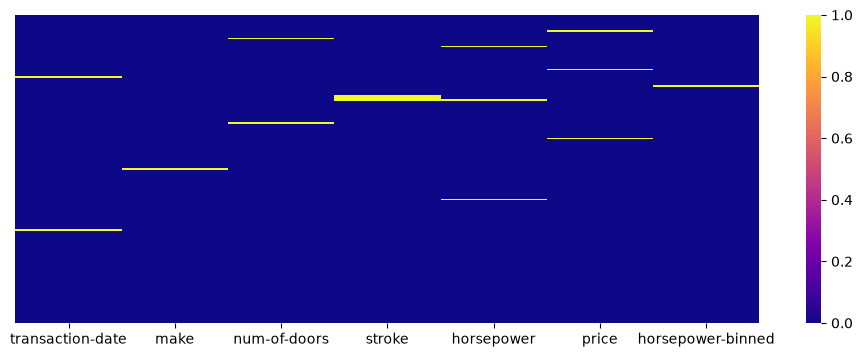

<Figure size 1000x1000 with 0 Axes>

In [45]:
missing_kolom = mobil.columns[mobil.isna().any()]
missing_df = mobil[missing_kolom]

plt.figure(figsize=(12, 4))
sns.heatmap(missing_df.isna(),
            cmap="plasma",
            cbar=True,
            yticklabels=False)
plt.figure(figsize=(10, 10))

In [46]:
mobil[mobil.isna().any(axis=1)]

,transaction-date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
10,01-11-2025,0,192,bmw,std,four,sedan,rwd,front,101.2,...,8.80,101.0,5800.0,23,29,NaN,10.217391,Low,0,1
15,16-Jan-2025,0,122,bmw,std,NaN,sedan,rwd,front,103.5,...,8.00,182.0,5400.0,16,22,41315.0,14.687500,High,0,1
20,2025-01-21,1,118,dodge,std,two,hatchback,fwd,front,93.7,...,9.41,NaN,5500.0,37,41,5572.0,6.351351,Low,0,1
35,05-Feb-2025,0,78,honda,std,four,wagon,fwd,front,96.5,...,9.20,76.0,6000.0,30,34,NaN,7.833333,Low,0,1
40,NaN,0,85,honda,std,four,sedan,fwd,front,96.5,...,9.00,101.0,5800.0,24,28,12945.0,9.791667,Low,0,1
46,02-16-2025,0,122,jaguar,std,two,sedan,rwd,front,102.0,...,11.50,262.0,5000.0,13,17,36000.0,18.076923,NaN,0,1
52,2025-02-22,3,150,mazda,std,two,hatchback,rwd,front,95.3,...,9.40,101.0,6000.0,17,23,10945.0,13.823529,Low,0,1
53,23/02/2025,3,150,mazda,std,two,hatchback,rwd,front,95.3,...,9.40,101.0,6000.0,17,23,11845.0,13.823529,Low,0,1
54,02-24-2025,3,150,mazda,std,two,hatchback,rwd,front,95.3,...,9.40,101.0,6000.0,17,23,13645.0,13.823529,Low,0,1
55,25-Feb-2025,3,150,mazda,std,two,hatchback,rwd,front,95.3,...,9.40,NaN,6000.0,16,23,15645.0,14.687500,Medium,0,1


In [47]:
mobil =  mobil.drop(columns=['transaction-date'])

##### Kategorik

In [48]:
mobil[kolom_kategorik].isna().sum()

make                 1
aspiration           0
num-of-doors         2
body-style           0
drive-wheels         0
engine-location      0
engine-type          0
num-of-cylinders     0
fuel-system          0
horsepower-binned    1
gas                  0
diesel               0
symboling            0
dtype: int64

In [49]:
for kolom in kolom_kategorik:
    mobil[kolom] = mobil[kolom].fillna(mobil[kolom].mode()[0])
mobil[kolom_kategorik].isna().sum()

make                 0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
engine-type          0
num-of-cylinders     0
fuel-system          0
horsepower-binned    0
gas                  0
diesel               0
symboling            0
dtype: int64

##### Numerik

In [50]:
print(mobil[kolom_numerik].isna().sum())

normalized-losses    0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-size          0
bore                 0
stroke               4
compression-ratio    0
horsepower           3
peak-rpm             0
city-mpg             0
highway-mpg          0
price                3
city-L/100km         0
dtype: int64


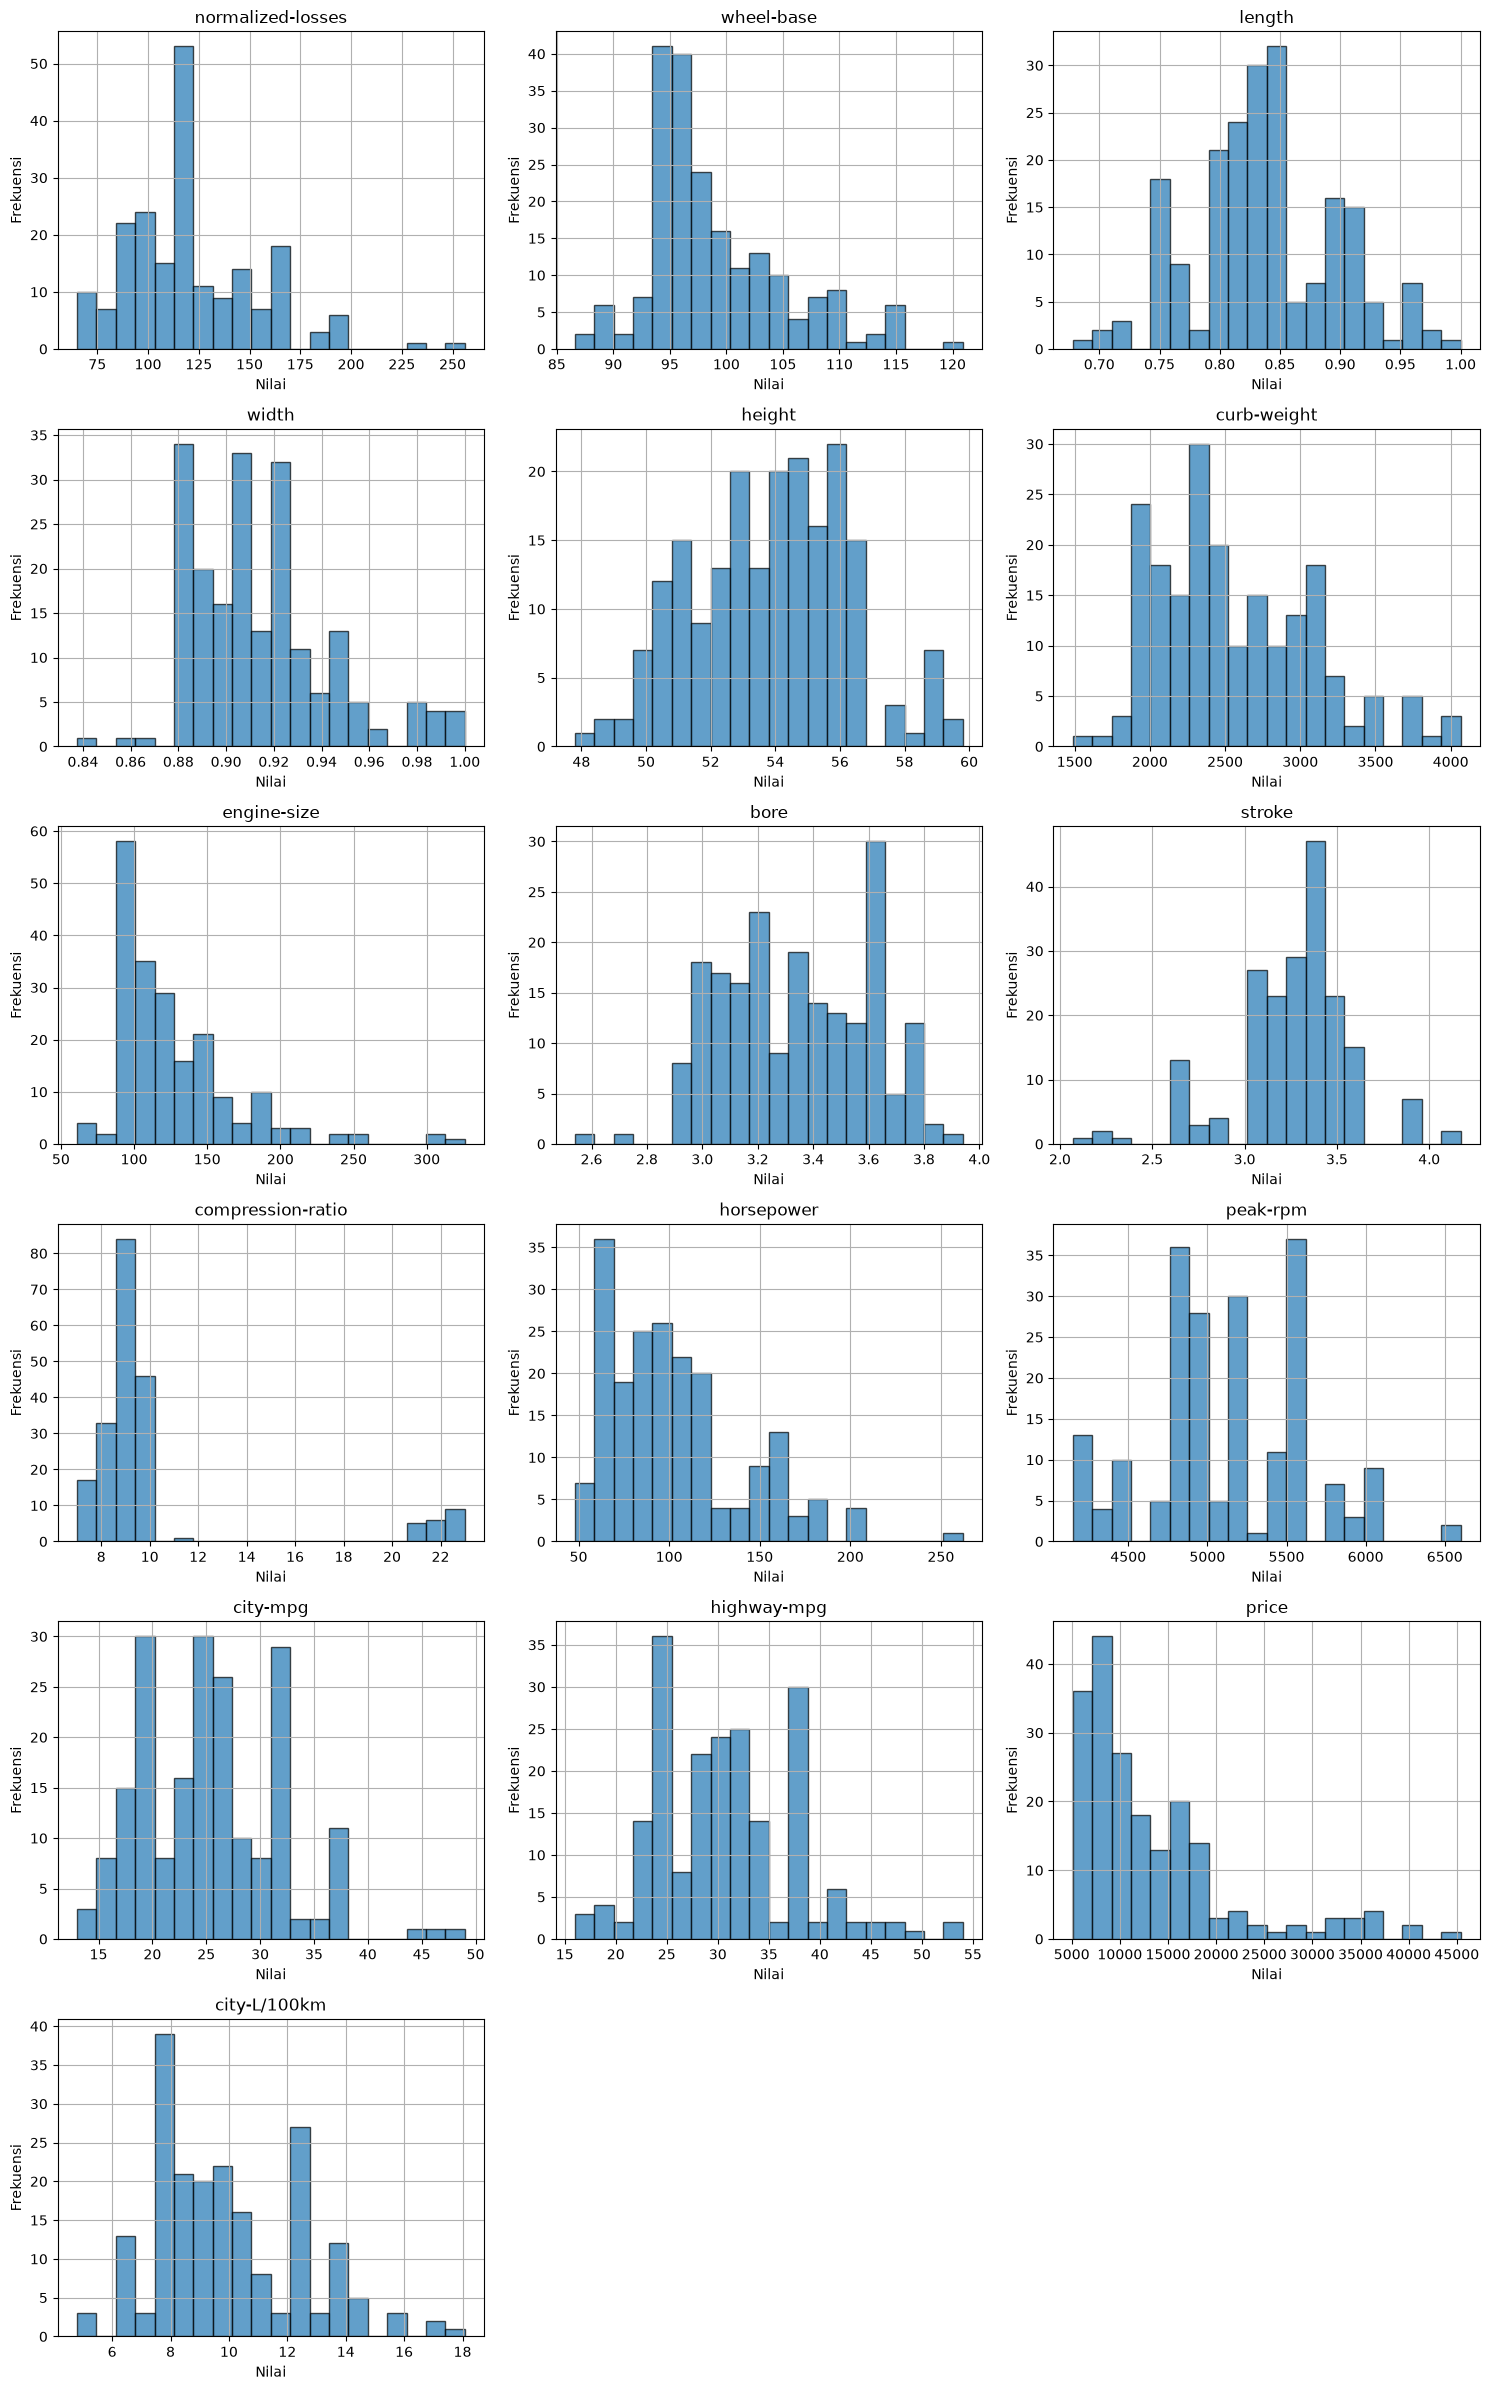

In [51]:
n_cols = 3
n_rows = (len(kolom_numerik) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))

axes = axes.flatten()

for ax, kolom in zip(axes, kolom_numerik):
    mobil[kolom].hist(ax=ax, bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(kolom)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')

for ax in axes[len(kolom_numerik):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [52]:
mobil[kolom_numerik] = mobil[kolom_numerik].fillna(mobil[kolom_numerik].median())
print(mobil[kolom_numerik].isna().sum())

normalized-losses    0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-size          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
city-L/100km         0
dtype: int64


In [53]:
print(mobil.isna().sum().sum())

0


In [54]:
mobil.shape

(201, 29)

#### Inconsistency

In [55]:
for kolom in kolom_kategorik:
    print(
        f"'{kolom}': \n {mobil[kolom].unique()}, \n \n",
    )

'make': 
 ['alfa-romero', 'ALFA-ROMERO', 'audi', 'bmw', 'chevrolet', ..., 'renault', 'saab', 'subaru', 'volkswagen', 'volvo']
Length: 27
Categories (27, str): ['ALFA-ROMERO', 'Audi', 'BMW', 'alfa-romero', ..., 'subaru', 'toyota', 'volkswagen', 'volvo'], 
 

'aspiration': 
 ['std', 'turbo']
Categories (2, str): ['std', 'turbo'], 
 

'num-of-doors': 
 ['two', 'four']
Categories (2, str): ['four', 'two'], 
 

'body-style': 
 ['convertible', 'hatchback', 'sedan', 'wagon', 'SEDAN', 'Sedan', 'hardtop']
Categories (7, str): ['SEDAN', 'Sedan', 'convertible', 'hardtop', 'hatchback', 'sedan', 'wagon'], 
 

'drive-wheels': 
 ['rwd', 'fwd', '4wd', 'AWD', 'RWD']
Categories (5, str): ['4wd', 'AWD', 'RWD', 'fwd', 'rwd'], 
 

'engine-location': 
 ['front', 'rear']
Categories (2, str): ['front', 'rear'], 
 

'engine-type': 
 ['dohc', 'ohcv', 'ohc', 'l', 'rotor', 'ohcf']
Categories (6, str): ['dohc', 'l', 'ohc', 'ohcf', 'ohcv', 'rotor'], 
 

'num-of-cylinders': 
 ['four', 'six', 'five', 'three', 'twelve

In [56]:
for kolom in kolom_kategorik:
    mobil[kolom] = mobil[kolom].str.lower()
    mobil[kolom] = mobil[kolom].str.strip()
    print(
        f"'{kolom}': \n {mobil[kolom].unique()}, \n \n",
    )

'make': 
 ['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'toyota' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'volkswagen' 'volvo'], 
 

'aspiration': 
 ['std' 'turbo'], 
 

'num-of-doors': 
 ['two' 'four'], 
 

'body-style': 
 ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop'], 
 

'drive-wheels': 
 ['rwd' 'fwd' '4wd' 'awd'], 
 

'engine-location': 
 ['front' 'rear'], 
 

'engine-type': 
 ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf'], 
 

'num-of-cylinders': 
 ['four' 'six' 'five' 'three' 'twelve' 'two' 'eight'], 
 

'fuel-system': 
 ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi'], 
 

'horsepower-binned': 
 ['medium' 'low' 'high'], 
 

'gas': 
 <StringArray>
['1', '0']
Length: 2, dtype: str, 
 

'diesel': 
 <StringArray>
['0', '1']
Length: 2, dtype: str, 
 

'symboling': 
 <StringArray>
['3', '1', '2', '0', '-1', '-2']
Length: 6, dtype: str, 
 



### Data Transformation

In [57]:
mobil[kolom_numerik].describe()

,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km
count,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,122.00000,98.797015,0.837102,0.915126,53.766667,2555.666667,126.875622,3.330692,3.257562,10.164279,103.375683,5117.665368,25.179104,30.686567,13165.940299,9.944145
std,31.99625,6.066366,0.059213,0.029187,2.447822,517.296727,41.546834,0.268072,0.316082,4.004965,37.213021,478.113805,6.423220,6.815150,7938.883492,2.534599
min,65.00000,86.600000,0.678039,0.837500,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918
25%,101.00000,94.500000,0.801538,0.890278,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000,7.833333
50%,122.00000,97.000000,0.832292,0.909722,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10270.000000,9.791667
75%,137.00000,102.400000,0.881788,0.925000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421
max,256.00000,120.900000,1.000000,1.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923


In [58]:
range = mobil[kolom_numerik].max() - mobil[kolom_numerik].min()
range_sort = range.sort_values(ascending=False)

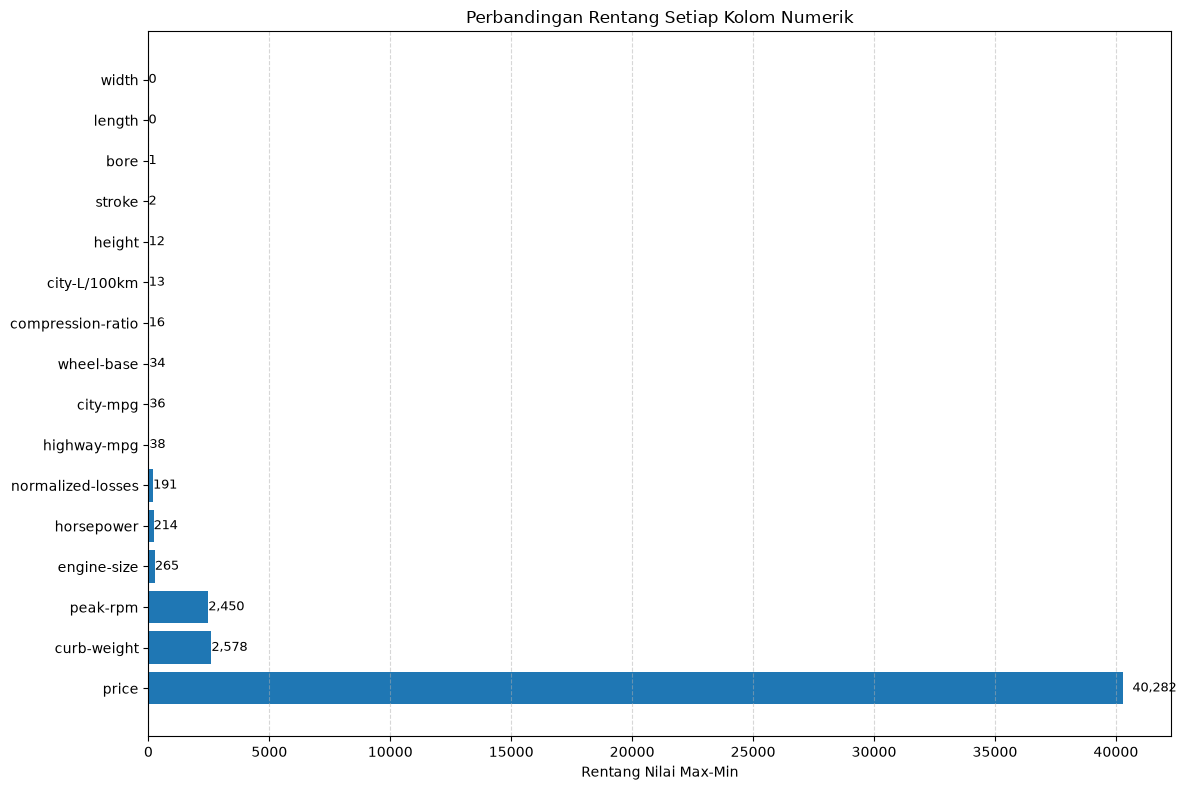

In [59]:
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range_sort.index, range_sort.values)
ax.set_xlabel('Rentang Nilai Max-Min')
ax.set_title('Perbandingan Rentang Setiap Kolom Numerik')
ax.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    width = bar.get_width()
    ax.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [60]:
print(range)

normalized-losses      191.000000
wheel-base              34.300000
length                   0.321961
width                    0.162500
height                  12.000000
curb-weight           2578.000000
engine-size            265.000000
bore                     1.400000
stroke                   2.100000
compression-ratio       16.000000
horsepower             214.000000
peak-rpm              2450.000000
city-mpg                36.000000
highway-mpg             38.000000
price                40282.000000
city-L/100km            13.281005
dtype: float64


#### Normalisasi

In [61]:
kolom_to_be_scaled = [kol for kol in kolom_numerik if kol not in ["width","bore"]]

In [62]:
scaler = MinMaxScaler()
mobil_scale = scaler.fit_transform(mobil[kolom_to_be_scaled])
mobil[kolom_to_be_scaled] = mobil_scale

In [63]:
print(mobil.shape)
print(mobil.columns)

(201, 29)
Index(['symboling', 'normalized-losses', 'make', 'aspiration', 'num-of-doors',
       'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length',
       'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders',
       'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio',
       'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price',
       'city-L/100km', 'horsepower-binned', 'diesel', 'gas'],
      dtype='str')


#### Encoding

In [87]:
mobil[['horsepower-binned','make', 'aspiration', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'fuel-system']] #before

,horsepower-binned,make,aspiration,body-style,drive-wheels,engine-location,engine-type,fuel-system
0,medium,alfa-romero,std,convertible,rwd,front,dohc,mpfi
1,medium,alfa-romero,std,convertible,rwd,front,dohc,mpfi
2,medium,alfa-romero,std,hatchback,rwd,front,ohcv,mpfi
3,medium,audi,std,sedan,fwd,front,ohc,mpfi
4,medium,audi,std,sedan,4wd,front,ohc,mpfi
...,...,...,...,...,...,...,...,...
196,medium,volvo,std,sedan,rwd,front,ohc,mpfi
197,high,volvo,turbo,sedan,rwd,front,ohc,mpfi
198,medium,volvo,std,sedan,rwd,front,ohcv,mpfi
199,medium,volvo,turbo,sedan,rwd,front,ohc,idi


> OHE

In [65]:
kolom_ohe = ['aspiration', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'fuel-system']

In [66]:
encoder = OneHotEncoder(drop=None, sparse_output=False)
encode_array = encoder.fit_transform(mobil[kolom_ohe])
encode_kolom = encoder.get_feature_names_out(kolom_ohe)
mobil_ohe = pd.DataFrame(encode_array, columns=encode_kolom, index=mobil.index)

> Ordinal Encoding

In [67]:
ord_enc = OrdinalEncoder(categories=[['low', 'medium', 'high']])
mobil['horsepower_ordinal'] = ord_enc.fit_transform(mobil[['horsepower-binned']])

In [68]:
mobil['horsepower_ordinal']

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
196    1.0
197    2.0
198    1.0
199    1.0
200    1.0
Name: horsepower_ordinal, Length: 201, dtype: float64

> Frequency Encoder

In [69]:
encoder = FrequencyEncoder()
mobil['make_freq'] = encoder.fit_transform(mobil[['make']])

In [70]:
mobil['make_freq']

0      0.014925
1      0.014925
2      0.014925
3      0.034826
4      0.034826
         ...   
196    0.054726
197    0.054726
198    0.054726
199    0.054726
200    0.054726
Name: make_freq, Length: 201, dtype: float64

In [71]:
mobil_final = pd.concat([mobil.drop(columns=kolom_ohe + ['make', 'horsepower-binned']), mobil_ohe], axis=1)

In [86]:
mobil_final[['horsepower_ordinal', 'make_freq', 'aspiration_std',
       'aspiration_turbo', 'body-style_convertible', 'body-style_hardtop',
       'body-style_hatchback', 'body-style_sedan', 'body-style_wagon',
       'drive-wheels_4wd', 'drive-wheels_awd', 'drive-wheels_fwd',
       'drive-wheels_rwd', 'engine-location_front', 'engine-location_rear',
       'engine-type_dohc', 'engine-type_l', 'engine-type_ohc',
       'engine-type_ohcf', 'engine-type_ohcv', 'engine-type_rotor',
       'fuel-system_1bbl', 'fuel-system_2bbl', 'fuel-system_4bbl',
       'fuel-system_idi', 'fuel-system_mfi', 'fuel-system_mpfi',
       'fuel-system_spdi', 'fuel-system_spfi']] # After

,horsepower_ordinal,make_freq,aspiration_std,aspiration_turbo,body-style_convertible,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon,drive-wheels_4wd,...,engine-type_ohcv,engine-type_rotor,fuel-system_1bbl,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,1.0,0.014925,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.014925,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.014925,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.034826,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.034826,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,1.0,0.054726,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
197,2.0,0.054726,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
198,1.0,0.054726,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
199,1.0,0.054726,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [73]:
print(mobil_final.shape)
print(mobil_final.columns)

(201, 50)
Index(['symboling', 'normalized-losses', 'num-of-doors', 'wheel-base',
       'length', 'width', 'height', 'curb-weight', 'num-of-cylinders',
       'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower',
       'peak-rpm', 'city-mpg', 'highway-mpg', 'price', 'city-L/100km',
       'diesel', 'gas', 'horsepower_ordinal', 'make_freq', 'aspiration_std',
       'aspiration_turbo', 'body-style_convertible', 'body-style_hardtop',
       'body-style_hatchback', 'body-style_sedan', 'body-style_wagon',
       'drive-wheels_4wd', 'drive-wheels_awd', 'drive-wheels_fwd',
       'drive-wheels_rwd', 'engine-location_front', 'engine-location_rear',
       'engine-type_dohc', 'engine-type_l', 'engine-type_ohc',
       'engine-type_ohcf', 'engine-type_ohcv', 'engine-type_rotor',
       'fuel-system_1bbl', 'fuel-system_2bbl', 'fuel-system_4bbl',
       'fuel-system_idi', 'fuel-system_mfi', 'fuel-system_mpfi',
       'fuel-system_spdi', 'fuel-system_spfi'],
      dtype='str')


In [74]:
processed = pd.read_csv('real/automobile_processed.csv')
print(processed.columns)

Index(['symboling', 'normalized-losses', 'num-of-doors', 'wheel-base',
       'length', 'width', 'height', 'curb-weight', 'num-of-cylinders',
       'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower',
       'peak-rpm', 'city-mpg', 'highway-mpg', 'price', 'city-L/100km',
       'diesel', 'gas', 'horsepower_ordinal', 'body-style_convertible',
       'body-style_hardtop', 'body-style_hatchback', 'body-style_sedan',
       'body-style_wagon', 'drive-wheels_4wd', 'drive-wheels_awd',
       'drive-wheels_fwd', 'drive-wheels_rwd', 'aspiration_std',
       'aspiration_turbo', 'engine-type_dohc', 'engine-type_l',
       'engine-type_ohc', 'engine-type_ohcf', 'engine-type_ohcv',
       'engine-type_rotor', 'engine-location_front', 'engine-location_rear',
       'fuel-system_1bbl', 'fuel-system_2bbl', 'fuel-system_4bbl',
       'fuel-system_idi', 'fuel-system_mfi', 'fuel-system_mpfi',
       'fuel-system_spdi', 'fuel-system_spfi', 'make_freq'],
      dtype='str')


In [75]:
assert set(mobil_final.columns) == set(processed.columns)

In [76]:
mobil_final.to_csv('data/processed/automobileEDA_processed_non_pipeline.csv')

#### Pipeline

In [77]:
class CleanTeks(BaseEstimator, TransformerMixin):
    """
    Lowercasing dan strip
    """

    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X= pd.DataFrame(X)
        for col in X.columns:
            X[col] = X[col].astype(str).str.lower().str.strip()
        return X
    def get_feature_names_out(self, input_feature=None):
        return input_feature

In [78]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """
    Frequency encoder: mengganti kategori dengan frekuensi relatifnya.
    Mapping dihitung saat fit dan disimpan untuk dipakai saat transform.
    """

    def __init__(self, unseen_value=0.0):
        self.unseen_value = unseen_value
        self.freq_map_ = None

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            col = X.iloc[:, 0]
        elif isinstance(X, pd.Series):
            col = X
        else:
            col = pd.Series(X[:, 0])
        self.freq_map_ = col.value_counts(normalize=True).to_dict()
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            col = X.iloc[:, 0]
        elif isinstance(X, pd.Series):
            col = X
        else:
            col = pd.Series(X[:, 0])
        return col.map(self.freq_map_).fillna(self.unseen_value).values.reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return ["frequency_encoded"]

##### Extract

In [79]:
def ekstrak_data():
    raw_path = os.path.join("data", "raw", "automobileEDA_dirty_training.csv")
    df = pd.read_csv(raw_path)
    print(f"[Extract] Data dimuat dari {raw_path}, shape: {df.shape}")
    return df

##### Transform

In [80]:
def check_initial_condition(df):
    """
    Menampilkan informasi awal dataset (opsional, untuk keperluan logging).
    """
    print("\n[Check] Kondisi awal dataset:")
    print(f"  - Jumlah baris : {df.shape[0]}")
    print(f"  - Jumlah kolom : {df.shape[1]}")
    print(f"  - Duplikat     : {df.duplicated().sum()}")
    print(f"  - Missing value total: {df.isna().sum().sum()}")
    print("  - Tipe data    :")
    print(df.dtypes.value_counts().to_string())

In [81]:
def build_preprocessing_pipeline():
    """
    Membangun pipeline preprocessing lengkap.
    Pipeline mencakup drop duplikat, imputasi, scaling, encoding,
    dan pembersihan teks.
    """

    kolom_numerik = [
        'normalized-losses', 'wheel-base', 'length', 'height', 'curb-weight',
        'engine-size', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm',
        'city-mpg', 'highway-mpg', 'price', 'city-L/100km'
    ]
    kolom_scale = kolom_numerik
    kolom_no_scale = ['width', 'bore']

    kolom_ohe = [
        'aspiration', 'body-style', 'drive-wheels',
        'engine-location', 'engine-type', 'fuel-system'
    ]

    kolom_ordinal = ['horsepower-binned']
    kolom_freq = ['make']
    kolom_passthrough_cat = [
        'num-of-doors', 'num-of-cylinders', 'symboling', 'diesel', 'gas'
    ]

    # 1. Drop duplikat
    def drop_duplicates_df(X):
        if isinstance(X, pd.DataFrame):
            return X.drop_duplicates().reset_index(drop=True)
        else:
            return np.unique(X, axis=0)

    drop_duplicates_transformer = FunctionTransformer(
        drop_duplicates_df,
        validate=False,
        feature_names_out=lambda self, input_features: input_features
    )

    # 2. Konversi ke str utk passthrough
    to_str_transformer = FunctionTransformer(
        lambda X: X.astype(str),
        validate=False,
        feature_names_out=lambda self, input_features: input_features
    )

    # 3. Tambahan dikit
    def ordinal_renamer(X):
        return X

    ordinal_renamer_transformer = FunctionTransformer(
        ordinal_renamer,
        feature_names_out=lambda self, input_features: ['horsepower_ordinal']
    )

    # Kolom Transform
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_scale', Pipeline([
                ('impute', SimpleImputer(strategy='median')),
                ('scale', MinMaxScaler())
            ]), kolom_scale),

            ('num_no_scale', Pipeline([
                ('impute', SimpleImputer(strategy='median'))
            ]), kolom_no_scale),

            ('cat_ohe', Pipeline([
                ('impute', SimpleImputer(strategy='most_frequent')),
                ('clean', CleanTeks()),
                ('ohe', OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore'))
            ]), kolom_ohe),

            ('cat_ordinal', Pipeline([
                ('impute', SimpleImputer(strategy='most_frequent')),
                ('clean', CleanTeks()),
                ('ordinal', OrdinalEncoder(categories=[['low', 'medium', 'high']])),
                ('rename', ordinal_renamer_transformer)
            ]), kolom_ordinal),

            ('cat_freq', Pipeline([
                ('impute', SimpleImputer(strategy='most_frequent')),
                ('clean', CleanTeks()),
                ('freq', FrequencyEncoder())
            ]), kolom_freq),

            ('cat_passthrough', Pipeline([
                ('to_str', to_str_transformer),
                ('impute', SimpleImputer(strategy='most_frequent'))
            ]), kolom_passthrough_cat)
        ],
        remainder='drop',
        verbose_feature_names_out=False
    )

    pipeline = Pipeline([
        ('drop_duplicates', drop_duplicates_transformer),
        ('preprocess', preprocessor)
    ])
    return pipeline

In [82]:
def transform_data(df, pipeline):
    """
    Menjalankan pipeline transformasi pada data.
    Mengembalikan DataFrame hasil preprocessing.
    """

    pipeline.fit(df)
    transformed = pipeline.transform(df)

    preprocessor = pipeline.named_steps['preprocess']
    ohe = preprocessor.named_transformers_['cat_ohe'].named_steps['ohe']
    kolom_ohe = ['aspiration', 'body-style', 'drive-wheels',
                 'engine-location', 'engine-type', 'fuel-system']
    ohe_columns = []
    for i, col in enumerate(kolom_ohe):
        for cat in ohe.categories_[i]:
            ohe_columns.append(f"{col}_{cat}")

    kolom_scale = [
        'normalized-losses', 'wheel-base', 'length', 'height', 'curb-weight',
        'engine-size', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm',
        'city-mpg', 'highway-mpg', 'price', 'city-L/100km'
    ]
    kolom_no_scale = ['width', 'bore']
    kolom_passthrough_cat = ['num-of-doors', 'num-of-cylinders',
                             'symboling', 'diesel', 'gas']

    feature_names = (
        kolom_scale +
        kolom_no_scale +
        ohe_columns +
        ['horsepower_ordinal'] +
        ['make_freq'] +
        kolom_passthrough_cat
    )

    assert len(feature_names) == transformed.shape[1], \
        f"Jumlah nama tidak cocok: {len(feature_names)} vs {transformed.shape[1]}"

    processed_df = pd.DataFrame(transformed, columns=feature_names)

    print(f"  - Shape hasil: {processed_df.shape}")
    print("  - Nama kolom (50 kolom):")
    print(processed_df.columns.tolist())
    return processed_df

##### Load

In [83]:
def load_data(df, output_filename="automobileEDA_processed_pipeline.csv"):
    """
    Menyimpan DataFrame hasil ke folder data/processed/.
    """
    output_dir = os.path.join("data", "processed")
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, output_filename)
    df.to_csv(output_path, index=False)
    print(f"\n{output_path}")

##### Run Pipeline

In [84]:
def run_pipeline():
    """
    Menjalankan seluruh tahapan ETL:
    Extract -> Transform -> Load
    """

    # Extract
    raw_df = ekstrak_data()

    # Transform
    check_initial_condition(raw_df)
    pipeline = build_preprocessing_pipeline()
    processed_df = transform_data(raw_df, pipeline)

    # Load
    load_data(processed_df)



if __name__ == "__main__":
    run_pipeline()

[Extract] Data dimuat dari data\raw\automobileEDA_dirty_training.csv, shape: (205, 30)

[Check] Kondisi awal dataset:
  - Jumlah baris : 205
  - Jumlah kolom : 30
  - Duplikat     : 4
  - Missing value total: 17
  - Tipe data    :
str        11
float64    11
int64       8
  - Shape hasil: (201, 50)
  - Nama kolom (50 kolom):
['normalized-losses', 'wheel-base', 'length', 'height', 'curb-weight', 'engine-size', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price', 'city-L/100km', 'width', 'bore', 'aspiration_std', 'aspiration_turbo', 'body-style_convertible', 'body-style_hardtop', 'body-style_hatchback', 'body-style_sedan', 'body-style_wagon', 'drive-wheels_4wd', 'drive-wheels_awd', 'drive-wheels_fwd', 'drive-wheels_rwd', 'engine-location_front', 'engine-location_rear', 'engine-type_dohc', 'engine-type_l', 'engine-type_ohc', 'engine-type_ohcf', 'engine-type_ohcv', 'engine-type_rotor', 'fuel-system_1bbl', 'fuel-system_2bbl', 'fuel-system_4bbl', 'fuel